In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
salud = "/workspaces/correaliesel138-a11y-intro-ml/data/raw/Global Health Statistics.csv" #ESTE LINK ES DEL DATASET QUE ESTA EN LA PAGINA DE KAGGLE
df = pd.read_csv(salud)
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 22 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   Country                             1000000 non-null  object 
 1   Year                                1000000 non-null  int64  
 2   Disease Name                        1000000 non-null  object 
 3   Disease Category                    1000000 non-null  object 
 4   Prevalence Rate (%)                 1000000 non-null  float64
 5   Incidence Rate (%)                  1000000 non-null  float64
 6   Mortality Rate (%)                  1000000 non-null  float64
 7   Age Group                           1000000 non-null  object 
 8   Gender                              1000000 non-null  object 
 9   Population Affected                 1000000 non-null  int64  
 10  Healthcare Access (%)               1000000 non-null  float64
 11  Doctors per 

In [4]:
#print(df['country'].head(20))
df = df.drop_duplicates(subset = df.columns.difference(['PassengerId']))
print(df.shape)
df.head()

(1000000, 22)


,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,...,Hospital Beds per 1000,Treatment Type,Average Treatment Cost (USD),Availability of Vaccines/Treatment,Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
0,Italy,2013,Malaria,Respiratory,0.95,1.55,8.42,0-18,Male,471007,...,7.58,Medication,21064,No,91.82,4493,2.16,16886,0.79,86.02
1,France,2002,Ebola,Parasitic,12.46,8.63,8.75,61+,Male,634318,...,5.11,Surgery,47851,Yes,76.65,2366,4.82,80639,0.74,45.52
2,Turkey,2015,COVID-19,Genetic,0.91,2.35,6.22,36-60,Male,154878,...,3.49,Vaccination,27834,Yes,98.55,41,5.81,12245,0.41,40.20
3,Indonesia,2011,Parkinson's Disease,Autoimmune,4.68,6.29,3.99,0-18,Other,446224,...,8.44,Surgery,144,Yes,67.35,3201,2.22,49336,0.49,58.47
4,Italy,2013,Tuberculosis,Genetic,0.83,13.59,7.01,61+,Male,472908,...,5.90,Medication,8908,Yes,50.06,2832,6.93,47701,0.50,48.14


In [5]:
#df.drop("PassengerId", axis = 1).duplicated().sum()
#df.duplicated().sum()
#df.drop(, axis = 1).duplicated().sum() #

print(df['Country'].value_counts())

Country
Russia          50532
South Africa    50408
South Korea     50181
Germany         50176
UK              50125
Canada          50114
Mexico          50080
China           50066
Nigeria         50046
Saudi Arabia    49958
Australia       49953
France          49943
USA             49913
Turkey          49901
Italy           49839
Argentina       49798
Japan           49764
India           49760
Indonesia       49756
Brazil          49687
Name: count, dtype: int64


In [6]:
print(df['Country'].unique())
print(f"Total países: {df['Country'].nunique()}")

['Italy' 'France' 'Turkey' 'Indonesia' 'Saudi Arabia' 'USA' 'Nigeria'
 'Australia' 'Canada' 'Mexico' 'China' 'South Africa' 'Japan' 'UK'
 'Russia' 'Brazil' 'Germany' 'India' 'Argentina' 'South Korea']


Total países: 20


In [7]:
print(f"nombre de enfermedades: {df['Disease Name'].value_counts().shape[0]}")
print(df['Disease Name'].value_counts())
print(df['Disease Name'].unique())
print(f"Total enfermedades: {df['Disease Name'].nunique()}")

nombre de enfermedades: 20
Disease Name
COVID-19               50404
Zika                   50313
Dengue                 50289
Cancer                 50285
HIV/AIDS               50274
Cholera                50249
Asthma                 50122
Leprosy                50064
Diabetes               50020
Rabies                 49975
Hepatitis              49970
Polio                  49956
Malaria                49948
Influenza              49919
Tuberculosis           49862
Alzheimer's Disease    49823
Measles                49736
Parkinson's Disease    49708
Ebola                  49692
Hypertension           49391
Name: count, dtype: int64
['Malaria' 'Ebola' 'COVID-19' "Parkinson's Disease" 'Tuberculosis'
 'Dengue' 'Rabies' 'Cholera' 'Leprosy' 'Cancer' 'Diabetes' 'Measles'
 'Zika' "Alzheimer's Disease" 'Polio' 'Hypertension' 'Asthma' 'HIV/AIDS'
 'Influenza' 'Hepatitis']
Total enfermedades: 20


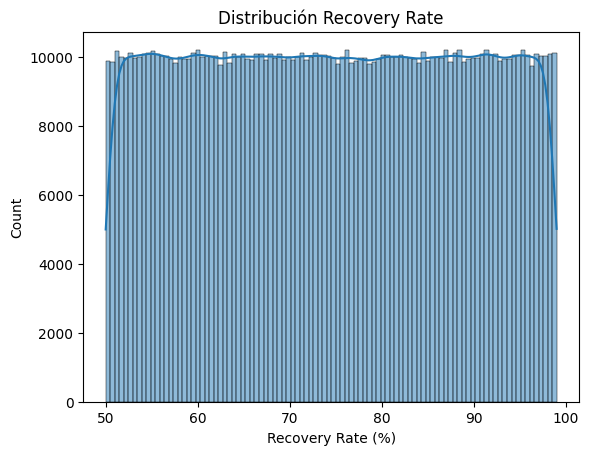

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Recovery Rate (%)"], kde=True)
plt.title("Distribución Recovery Rate")
plt.show()

In [15]:
# Elegir el país que quieres consultar
pais = "Japan"  # cambia por el país que quieras

# Cuántas enfermedades hay en ese país
print(f"Total enfermedades en {pais}: {df[df['Country'] == pais]['Disease Name'].nunique()}")

# Cuáles son
print(df[df['Country'] == pais]['Disease Name'].unique())

Total enfermedades en Japan: 20
['Diabetes' "Alzheimer's Disease" 'Malaria' 'Tuberculosis' 'Influenza'
 'Zika' 'Dengue' 'Rabies' 'Hypertension' 'Leprosy' "Parkinson's Disease"
 'Ebola' 'HIV/AIDS' 'COVID-19' 'Cancer' 'Hepatitis' 'Polio' 'Measles'
 'Cholera' 'Asthma']


In [16]:
df.groupby('Country')['Disease Name'].nunique()

Country
Argentina       20
Australia       20
Brazil          20
Canada          20
China           20
France          20
Germany         20
India           20
Indonesia       20
Italy           20
Japan           20
Mexico          20
Nigeria         20
Russia          20
Saudi Arabia    20
South Africa    20
South Korea     20
Turkey          20
UK              20
USA             20
Name: Disease Name, dtype: int64

In [17]:
df[df['Country'] == pais]['Disease Name'].value_counts()

Disease Name
HIV/AIDS               2611
Zika                   2555
Tuberculosis           2536
Ebola                  2524
Leprosy                2524
Dengue                 2521
Diabetes               2509
Cancer                 2493
Alzheimer's Disease    2487
COVID-19               2482
Asthma                 2475
Malaria                2473
Influenza              2472
Rabies                 2470
Hypertension           2449
Measles                2447
Polio                  2439
Parkinson's Disease    2438
Cholera                2431
Hepatitis              2428
Name: count, dtype: int64

In [18]:

print(f"nombre de categorías de enfermedades: {df['Disease Category'].value_counts().shape[0]}")
print(df['Disease Category'].value_counts())
print(df['Disease Category'].value_counts())
print(df['Disease Category'].unique())
print(f"Total enfermedades: {df['Disease Category'].nunique()}")

nombre de categorías de enfermedades: 11
Disease Category
Metabolic         91332
Parasitic         91178
Genetic           91153
Autoimmune        91153
Neurological      91000
Cardiovascular    90968
Viral             90910
Infectious        90764
Respiratory       90588
Bacterial         90509
Chronic           90445
Name: count, dtype: int64
Disease Category
Metabolic         91332
Parasitic         91178
Genetic           91153
Autoimmune        91153
Neurological      91000
Cardiovascular    90968
Viral             90910
Infectious        90764
Respiratory       90588
Bacterial         90509
Chronic           90445
Name: count, dtype: int64
['Respiratory' 'Parasitic' 'Genetic' 'Autoimmune' 'Bacterial'
 'Cardiovascular' 'Neurological' 'Chronic' 'Metabolic' 'Infectious'
 'Viral']
Total enfermedades: 11


In [19]:
pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
  
# metadata 
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata) 
  
# variable information 
print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

/home/vscode/.local/lib/python3.11/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [27]:
df1 = pd.read_csv("/workspaces/correaliesel138-a11y-intro-ml/data/raw/diabetic_data.csv")
df2 = pd.read_csv("/workspaces/correaliesel138-a11y-intro-ml/data/raw/IDS_mapping.csv")

# Ver columnas de cada uno
print("Columnas df1:", df1.columns.tolist())
print("Columnas df2:", df2.columns.tolist())

# Ver dimensiones
print("Shape df1:", df1.shape)
print("Shape df2:", df2.shape)

Columnas df1: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']
Columnas df2: ['admission_type_id', 'description']
Shape df1: (101766, 50)
Shape df2: (67, 2)


In [28]:
df_total = pd.merge(df1, df2, on="admission_type_id", how="left")

# Ver resultado
print(df_total.shape)
print(df_total.head())

ValueError: You are trying to merge on int64 and object columns for key 'admission_type_id'. If you wish to proceed you should use pd.concat

In [29]:
# Convertir ambos a string o ambos a int
df1['admission_type_id'] = df1['admission_type_id'].astype(str)
df2['admission_type_id'] = df2['admission_type_id'].astype(str)

# Ahora sí hacer el merge
df_total = pd.merge(df1, df2, on="admission_type_id", how="left")

print(df_total.shape)
print(df_total.head())

(305298, 51)
   encounter_id  patient_nbr       race  gender      age weight  \
0       2278392      8222157  Caucasian  Female   [0-10)      ?   
1       2278392      8222157  Caucasian  Female   [0-10)      ?   
2       2278392      8222157  Caucasian  Female   [0-10)      ?   
3        149190     55629189  Caucasian  Female  [10-20)      ?   
4        149190     55629189  Caucasian  Female  [10-20)      ?   

  admission_type_id  discharge_disposition_id  admission_source_id  \
0                 6                        25                    1   
1                 6                        25                    1   
2                 6                        25                    1   
3                 1                         1                    7   
4                 1                         1                    7   

   time_in_hospital  ... insulin glyburide-metformin  glipizide-metformin  \
0                 1  ...      No                  No                   No   
1        

In [30]:
df_total.info()
print(df_total.shape)
print(df_total.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305298 entries, 0 to 305297
Data columns (total 51 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              305298 non-null  int64 
 1   patient_nbr               305298 non-null  int64 
 2   race                      305298 non-null  object
 3   gender                    305298 non-null  object
 4   age                       305298 non-null  object
 5   weight                    305298 non-null  object
 6   admission_type_id         305298 non-null  object
 7   discharge_disposition_id  305298 non-null  int64 
 8   admission_source_id       305298 non-null  int64 
 9   time_in_hospital          305298 non-null  int64 
 10  payer_code                305298 non-null  object
 11  medical_specialty         305298 non-null  object
 12  num_lab_procedures        305298 non-null  int64 
 13  num_procedures            305298 non-null  int64 
 14  num_

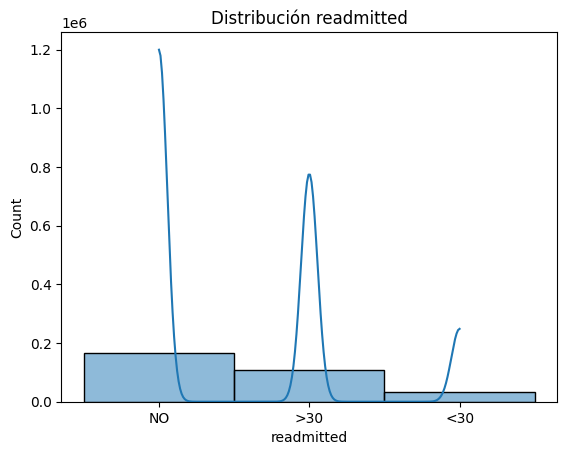

In [31]:
sns.histplot(df_total["readmitted"], kde=True)
plt.title("Distribución readmitted")
plt.show()